# K-Means Clustering on the Diana Dataset
## Identifying MOD, MARD, SIDD, and SIRD Phenotypes

---

### Objective
Perform K-means clustering (k=4) on the Diana dataset to identify four metabolic phenotypes:
- **SIRD** – Severe Insulin-Resistant Diabetes
- **SIDD** – Severe Insulin-Deficient Diabetes
- **MARD** – Mild Age-Related Diabetes
- **MOD** – Mild Obesity-Related Diabetes

### Constraint
HbA1c, FBS, systolic BP, and diastolic BP are **excluded**. Instead, we rely on demographics, adiposity, and lipid-metabolism **proxies** to uncover the underlying metabolic drivers.

### Engineered Proxy Features
| Proxy | Formula | Clinical Rationale |
|-------|---------|--------------------|
| **LAP** (Lipid Accumulation Product) | (Waist − 58) × Triglycerides | Visceral fat & insulin resistance marker |
| **Atherogenic Index (log TG/HDL)** | log₁₀(TG / HDL) | Metabolic syndrome differentiator |
| **LDL/HDL Ratio** | LDL / HDL | Atherogenic risk marker |
| **Adiposity Index** | BMI × Waist Circumference | Obesity-driven phenotype signal |

### Input Variables for Clustering
`age`, `bmi`, `waist_circumference`, `total_cholesterol`, `ldl`, `hdl`, `triglycerides`, `LAP`, `log_TG_HDL`, `LDL_HDL_ratio`, `adiposity_index`

### Pipeline
1. Data loading & inspection
2. Feature engineering (4 proxy variables)
3. MinMaxScaler normalization [0, 1]
4. K-Means clustering (k=4)
5. Cluster labeling based on systematic-review criteria
6. Profile table (medians per cluster)
7. Clinical focus & recommendations
8. Visualizations

---
## 1. Setup & Imports

In [42]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 2. Load Dataset

In [43]:
df = pd.read_csv('diana_dataset_binary.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (1376, 22)

Columns: ['SEQN', 'age', 'hba1c', 'fbs', 'bmi', 'total_cholesterol', 'ldl', 'hdl', 'triglycerides', 'systolic', 'diastolic', 'waist_circumference', 'family_history_diabetes', 'race_ethnicity', 'smoking_status', 'physical_activity', 'alcohol_use', 'cycle', 'diabetes_status', 'diabetes_label', 'menopausal_status', 'has_outlier']


,SEQN,age,hba1c,fbs,bmi,total_cholesterol,ldl,hdl,triglycerides,systolic,diastolic,waist_circumference,family_history_diabetes,race_ethnicity,smoking_status,physical_activity,alcohol_use,cycle,diabetes_status,diabetes_label,menopausal_status,has_outlier
0,130396.00,56.00,5.00,104.00,27.30,214.00,124.00,68.00,108.50,122.00,79.00,97.90,0,3,1,1,0,2021-2023,Normal,0,Postmenopausal,False
1,130416.00,59.00,5.30,91.00,32.90,189.00,126.00,47.00,90.80,135.00,85.00,88.30,0,2,0,1,0,2021-2023,Normal,0,Postmenopausal,False
2,130599.00,54.00,6.10,99.00,50.20,184.00,125.00,41.00,172.20,99.00,78.00,133.00,0,2,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False
3,130662.00,52.00,5.50,94.00,30.90,191.00,119.00,53.00,73.90,128.00,84.00,98.80,1,4,1,1,0,2021-2023,Normal,0,Postmenopausal,False
4,130703.00,51.00,5.90,115.00,39.20,207.00,102.00,49.00,200.50,123.00,93.00,126.20,1,6,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False


In [44]:
# Quick summary of the variables we will use
base_vars = ['age', 'bmi', 'waist_circumference', 'total_cholesterol', 'ldl', 'hdl', 'triglycerides']
print("Descriptive statistics for base clustering variables:\n")
df[base_vars].describe().round(2)

Descriptive statistics for base clustering variables:



,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides
count,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00
mean,54.59,31.09,101.59,209.34,125.67,58.89,124.63
std,4.11,7.97,16.70,42.15,37.55,16.59,75.55
min,45.00,13.60,66.30,86.00,24.00,23.00,24.00
25%,52.00,25.49,89.68,181.00,101.00,47.00,77.00
50%,55.00,29.70,100.10,207.00,123.00,56.00,106.70
75%,58.00,35.70,112.20,234.00,148.00,67.25,149.00
max,60.00,74.80,169.00,463.00,375.00,142.00,876.00


---
## 3. Feature Engineering

In [45]:
# --- Proxy 1: Lipid Accumulation Product (LAP) ---
# LAP = (Waist Circumference - 58) x Triglycerides
# A powerful proxy for visceral fat accumulation and insulin resistance.
df['LAP'] = (df['waist_circumference'] - 58) * df['triglycerides']

# --- Proxy 2: Atherogenic Index of Plasma (log TG/HDL) ---
# log10(Triglycerides / HDL)
# Differentiates metabolic syndrome (SIRD) from leaner phenotypes.
df['log_TG_HDL'] = np.log10(df['triglycerides'] / df['hdl'])

# --- Proxy 3: LDL/HDL Ratio ---
# Marker for atherogenic risk and metabolic dysfunction.
df['LDL_HDL_ratio'] = df['ldl'] / df['hdl']

# --- Proxy 4: Adiposity Index ---
# BMI x Waist Circumference
# Maximizes the signal for obesity-driven types (MOD and SIRD).
df['adiposity_index'] = df['bmi'] * df['waist_circumference']

proxy_vars = ['LAP', 'log_TG_HDL', 'LDL_HDL_ratio', 'adiposity_index']
print("Engineered proxy features:\n")
df[proxy_vars].describe().round(2)

Engineered proxy features:



,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index
count,1376.00,1376.00,1376.00,1376.00
mean,5658.81,0.28,2.30,3278.93
std,4430.86,0.31,0.95,1399.65
min,434.70,-0.60,0.41,1071.05
25%,2662.45,0.08,1.66,2266.44
50%,4518.60,0.27,2.14,2975.05
75%,7392.20,0.48,2.81,3985.72
max,52371.00,1.53,7.98,11813.10


---
## 4. Preprocessing — MinMaxScaler Normalization

In [46]:
# Full set of clustering features (7 base + 4 proxies = 11 features)
clustering_features = base_vars + proxy_vars
print(f"Clustering features ({len(clustering_features)}):")
for i, f in enumerate(clustering_features, 1):
    print(f"  {i}. {f}")

# Drop rows with any missing values in clustering features
df_clean = df.dropna(subset=clustering_features).copy()
print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")

# MinMaxScaler normalization to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[clustering_features])
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=df_clean.index)

print(f"\nScaled data shape: {X_scaled_df.shape}")
X_scaled_df.describe().round(3)

Clustering features (11):
  1. age
  2. bmi
  3. waist_circumference
  4. total_cholesterol
  5. ldl
  6. hdl
  7. triglycerides
  8. LAP
  9. log_TG_HDL
  10. LDL_HDL_ratio
  11. adiposity_index

Rows before cleaning: 1376
Rows after cleaning:  1376

Scaled data shape: (1376, 11)


,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index
count,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00
mean,0.64,0.29,0.34,0.33,0.29,0.30,0.12,0.10,0.41,0.25,0.21
std,0.27,0.13,0.16,0.11,0.11,0.14,0.09,0.09,0.14,0.12,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.47,0.19,0.23,0.25,0.22,0.20,0.06,0.04,0.32,0.17,0.11
50%,0.67,0.26,0.33,0.32,0.28,0.28,0.10,0.08,0.41,0.23,0.18
75%,0.87,0.36,0.45,0.39,0.35,0.37,0.15,0.13,0.51,0.32,0.27
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## 4b. Elbow Method — With Proxies vs. Without Proxies
Compare inertia (WCSS) and silhouette scores across k=2–10 for both feature sets to validate k=4.

,Inertia (With Proxies),Silhouette (With Proxies),Inertia (Without Proxies),Silhouette (Without Proxies)
k,,,,
2,242.59,0.24,159.86,0.29
3,197.58,0.22,133.01,0.23
4,172.67,0.22,117.57,0.21
5,155.41,0.20,107.57,0.20
6,144.81,0.17,98.32,0.19
7,135.17,0.18,91.11,0.19
8,127.80,0.17,86.00,0.18
9,121.45,0.17,81.46,0.18
10,115.90,0.17,77.38,0.18


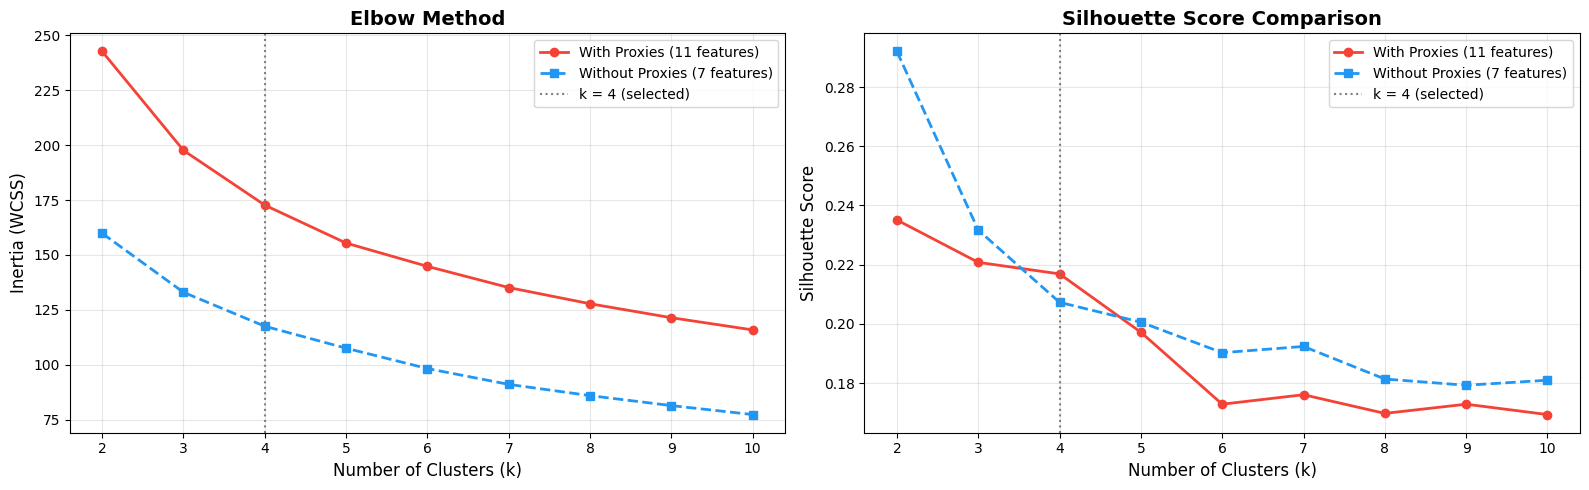

In [47]:
# --- Elbow Method: With Proxies vs. Without Proxies ---

k_range = range(2, 11)

# Scale base-only features (without proxies)
X_base_scaled = MinMaxScaler().fit_transform(df_clean[base_vars])

# Containers for results
results = []

for k_val in k_range:
    km_params = dict(n_clusters=k_val, init='k-means++', n_init=30, max_iter=500, random_state=42)

    # WITH proxies (11 features)
    km_proxy = KMeans(**km_params).fit(X_scaled)
    sil_proxy = silhouette_score(X_scaled, km_proxy.labels_)

    # WITHOUT proxies (7 base features)
    km_base = KMeans(**km_params).fit(X_base_scaled)
    sil_base = silhouette_score(X_base_scaled, km_base.labels_)

    results.append({
        'k': k_val,
        'Inertia (With Proxies)': round(km_proxy.inertia_, 2),
        'Silhouette (With Proxies)': round(sil_proxy, 4),
        'Inertia (Without Proxies)': round(km_base.inertia_, 2),
        'Silhouette (Without Proxies)': round(sil_base, 4)
    })

elbow_df = pd.DataFrame(results).set_index('k')
display(elbow_df)

# --- Side-by-side Elbow & Silhouette plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Inertia (Elbow)
axes[0].plot(k_range, elbow_df['Inertia (With Proxies)'], 'o-', color='#f44336', linewidth=2, label='With Proxies (11 features)')
axes[0].plot(k_range, elbow_df['Inertia (Without Proxies)'], 's--', color='#2196F3', linewidth=2, label='Without Proxies (7 features)')
axes[0].axvline(x=4, color='gray', linestyle=':', linewidth=1.5, label='k = 4 (selected)')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(k_range, elbow_df['Silhouette (With Proxies)'], 'o-', color='#f44336', linewidth=2, label='With Proxies (11 features)')
axes[1].plot(k_range, elbow_df['Silhouette (Without Proxies)'], 's--', color='#2196F3', linewidth=2, label='Without Proxies (7 features)')
axes[1].axvline(x=4, color='gray', linestyle=':', linewidth=1.5, label='k = 4 (selected)')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

---
## 5. K-Means Clustering (k = 4)

In [48]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=50, max_iter=500, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df_clean['cluster'])

# Display clustering summary as a table
summary_data = {
    'Metric': ['Algorithm', 'Number of Clusters (k)', 'Silhouette Score', 'Inertia (WCSS)', 'Total Samples'],
    'Value': ['K-Means++', k, f'{sil_score:.4f}', f'{kmeans.inertia_:.2f}', len(df_clean)]
}
display(pd.DataFrame(summary_data).style.hide(axis='index').set_caption('K-Means Clustering Summary'))

# Cluster distribution table
dist = df_clean['cluster'].value_counts().sort_index().reset_index()
dist.columns = ['Cluster', 'Count']
dist['Percentage'] = (dist['Count'] / len(df_clean) * 100).round(1).astype(str) + '%'
display(dist.style.hide(axis='index').set_caption('Cluster Distribution'))

Metric,Value
Algorithm,K-Means++
Number of Clusters (k),4
Silhouette Score,0.2169
Inertia (WCSS),172.67
Total Samples,1376


Cluster,Count,Percentage
0,264,19.2%
1,474,34.4%
2,344,25.0%
3,294,21.4%


---
## 6. Cluster Profiling — Median Table (Before Labeling)

In [49]:
# Compute median of all features per cluster (raw, unscaled values)
profile_raw = df_clean.groupby('cluster')[clustering_features].median().round(2)
profile_raw.index.name = 'Cluster'
print("Cluster medians (raw values):\n")
profile_raw

Cluster medians (raw values):



,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index
Cluster,,,,,,,,,,,
0,56.50,40.15,121.05,185.00,105.00,52.00,110.20,6964.80,0.33,1.99,4859.59
1,57.00,25.72,90.05,208.00,119.86,68.00,83.00,2530.40,0.09,1.76,2297.39
2,49.00,30.39,100.55,199.50,121.00,54.00,100.00,4283.46,0.26,2.23,3087.36
3,56.50,29.81,101.85,235.00,152.00,47.50,175.50,7459.95,0.57,3.22,3024.53


---
## 7. Cluster Labeling — Mapping to Metabolic Phenotypes

### Labeling Criteria (from systematic review):
| Phenotype | Key Features |
|-----------|-------------|
| **SIRD** | Highest LAP, TG/HDL ratio, and Waist Circumference |
| **SIDD** | Lower Age, low/normal BMI |
| **MARD** | Highest Age, relatively stable/mild lipid profiles |
| **MOD** | Younger age, moderate obesity (high BMI but lower LAP than SIRD) |

In [50]:
# --- Automated labeling based on systematic-review criteria ---

medians = df_clean.groupby('cluster')[clustering_features].median()
labels = {}
remaining_clusters = list(medians.index)

# 1. SIRD: highest LAP, highest log_TG_HDL, highest waist_circumference
sird_score = (
    medians.loc[remaining_clusters, 'LAP'].rank() +
    medians.loc[remaining_clusters, 'log_TG_HDL'].rank() +
    medians.loc[remaining_clusters, 'waist_circumference'].rank()
)
sird_cluster = sird_score.idxmax()
labels[sird_cluster] = 'SIRD'
remaining_clusters.remove(sird_cluster)

# 2. MARD: highest age among remaining, mild lipids
mard_cluster = medians.loc[remaining_clusters, 'age'].idxmax()
labels[mard_cluster] = 'MARD'
remaining_clusters.remove(mard_cluster)

# 3. SIDD vs MOD from the remaining two clusters
bmi_vals = medians.loc[remaining_clusters, 'bmi']
mod_cluster = bmi_vals.idxmax()
sidd_cluster = bmi_vals.idxmin()
labels[mod_cluster] = 'MOD'
labels[sidd_cluster] = 'SIDD'

# Map labels
df_clean['phenotype'] = df_clean['cluster'].map(labels)

# Display mapping as a table
mapping_rows = []
for c in sorted(labels.keys()):
    n = (df_clean['cluster'] == c).sum()
    pct = n / len(df_clean) * 100
    mapping_rows.append({'Cluster': c, 'Phenotype': labels[c], 'n': n, '%': f'{pct:.1f}%'})
display(pd.DataFrame(mapping_rows).style.hide(axis='index').set_caption('Cluster → Phenotype Mapping'))

Cluster,Phenotype,n,%
0,MOD,264,19.2%
1,MARD,474,34.4%
2,SIDD,344,25.0%
3,SIRD,294,21.4%


---
## 8. Profile Table — Median of All Features per Phenotype

In [51]:
phenotype_order = ['SIDD', 'SIRD', 'MOD', 'MARD']
profile_table = df_clean.groupby('phenotype')[clustering_features].median().round(2)
profile_table = profile_table.reindex(phenotype_order)
profile_table.index.name = 'Phenotype'

print("="*100)
print("PROFILE TABLE: Median of All Features per Metabolic Phenotype")
print("="*100)
display(profile_table)

PROFILE TABLE: Median of All Features per Metabolic Phenotype


,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index
Phenotype,,,,,,,,,,,
SIDD,49.00,30.39,100.55,199.50,121.00,54.00,100.00,4283.46,0.26,2.23,3087.36
SIRD,56.50,29.81,101.85,235.00,152.00,47.50,175.50,7459.95,0.57,3.22,3024.53
MOD,56.50,40.15,121.05,185.00,105.00,52.00,110.20,6964.80,0.33,1.99,4859.59
MARD,57.00,25.72,90.05,208.00,119.86,68.00,83.00,2530.40,0.09,1.76,2297.39


In [52]:
# Extended profile: Median [IQR] per Phenotype as a formatted table
iqr_rows = []
for pheno in phenotype_order:
    subset = df_clean[df_clean['phenotype'] == pheno]
    row = {'Phenotype': f'{pheno} (n={len(subset)})'}
    for feat in clustering_features:
        q1 = subset[feat].quantile(0.25)
        med = subset[feat].median()
        q3 = subset[feat].quantile(0.75)
        row[feat] = f'{med:.1f} [{q1:.1f}–{q3:.1f}]'
    iqr_rows.append(row)

iqr_table = pd.DataFrame(iqr_rows).set_index('Phenotype')
display(iqr_table.style.set_caption('Extended Profile: Median [IQR] per Phenotype'))

,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index
Phenotype,,,,,,,,,,,
SIDD (n=344),49.0 [47.0–51.0],30.4 [26.3–36.0],100.5 [90.9–111.3],199.5 [176.7–222.0],121.0 [101.8–143.0],54.0 [47.0–63.0],100.0 [74.0–134.4],4283.5 [2671.0–6632.7],0.3 [0.1–0.4],2.2 [1.7–2.8],3087.4 [2414.9–3984.0]
SIRD (n=294),56.5 [54.0–59.0],29.8 [26.8–33.4],101.8 [93.7–108.1],235.0 [214.0–265.8],152.0 [130.0–176.0],47.5 [41.0–53.0],175.5 [139.0–232.8],7459.9 [5241.0–10735.2],0.6 [0.4–0.7],3.2 [2.7–3.7],3024.5 [2543.9–3543.3]
MOD (n=264),56.5 [54.0–59.0],40.2 [36.7–44.5],121.0 [114.0–130.3],185.0 [162.8–209.2],105.0 [86.8–130.0],52.0 [45.0–60.0],110.2 [88.0–140.0],6964.8 [5295.8–8996.7],0.3 [0.2–0.5],2.0 [1.7–2.4],4859.6 [4191.4–5680.1]
MARD (n=474),57.0 [55.0–59.0],25.7 [22.3–28.8],90.0 [82.3–97.6],208.0 [184.0–232.0],119.9 [99.0–140.0],68.0 [60.0–79.0],83.0 [65.0–104.9],2530.4 [1679.7–3657.4],0.1 [-0.1–0.2],1.8 [1.4–2.1],2297.4 [1854.5–2832.7]


---
## 9. Clinical Focus & Recommendations

In [53]:
clinical_recs = {
    'SIRD': {
        'Description': 'Severe Insulin-Resistant Diabetes',
        'Key Features': 'Highest LAP, TG/HDL ratio, waist circumference — visceral adiposity & severe insulin resistance.',
        'Clinical Recommendations': 'Weight loss (GLP-1 RA, bariatric referral) · Insulin sensitizers (metformin, pioglitazone) · CV risk management · Screen NAFLD/NASH & OSA'
    },
    'SIDD': {
        'Description': 'Severe Insulin-Deficient Diabetes',
        'Key Features': 'Younger age, low/normal BMI — beta-cell dysfunction rather than obesity-driven resistance.',
        'Clinical Recommendations': 'Monitor beta-cell function (C-peptide, HOMA-B) · Early insulin/sulfonylurea consideration · Screen GAD65/IA-2 (rule out LADA) · Tight glycemic control'
    },
    'MARD': {
        'Description': 'Mild Age-Related Diabetes',
        'Key Features': 'Oldest group, stable mild lipid profiles — age-related metabolic decline.',
        'Clinical Recommendations': 'Conservative glycemic targets · Geriatric syndrome screening · Simplified regimens · Periodic goal reassessment'
    },
    'MOD': {
        'Description': 'Mild Obesity-Related Diabetes',
        'Key Features': 'Younger, moderate obesity (high BMI, lower LAP than SIRD) — obesity-driven but less metabolically severe.',
        'Clinical Recommendations': 'Structured weight management · Metformin first-line · Consider GLP-1 RA · Address modifiable risk factors · Behavioral counseling'
    }
}

rec_rows = []
for pheno in phenotype_order:
    info = clinical_recs[pheno]
    n = (df_clean['phenotype'] == pheno).sum()
    rec_rows.append({
        'Phenotype': f'{pheno} (n={n})',
        'Description': info['Description'],
        'Key Features': info['Key Features'],
        'Clinical Recommendations': info['Clinical Recommendations']
    })

rec_df = pd.DataFrame(rec_rows).set_index('Phenotype')
display(rec_df.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).set_caption('Clinical Focus & Recommendations per Phenotype'))

,Description,Key Features,Clinical Recommendations
Phenotype,,,
SIDD (n=344),Severe Insulin-Deficient Diabetes,"Younger age, low/normal BMI — beta-cell dysfunction rather than obesity-driven resistance.","Monitor beta-cell function (C-peptide, HOMA-B) · Early insulin/sulfonylurea consideration · Screen GAD65/IA-2 (rule out LADA) · Tight glycemic control"
SIRD (n=294),Severe Insulin-Resistant Diabetes,"Highest LAP, TG/HDL ratio, waist circumference — visceral adiposity & severe insulin resistance.","Weight loss (GLP-1 RA, bariatric referral) · Insulin sensitizers (metformin, pioglitazone) · CV risk management · Screen NAFLD/NASH & OSA"
MOD (n=264),Mild Obesity-Related Diabetes,"Younger, moderate obesity (high BMI, lower LAP than SIRD) — obesity-driven but less metabolically severe.",Structured weight management · Metformin first-line · Consider GLP-1 RA · Address modifiable risk factors · Behavioral counseling
MARD (n=474),Mild Age-Related Diabetes,"Oldest group, stable mild lipid profiles — age-related metabolic decline.",Conservative glycemic targets · Geriatric syndrome screening · Simplified regimens · Periodic goal reassessment


---
## 10. Visualizations

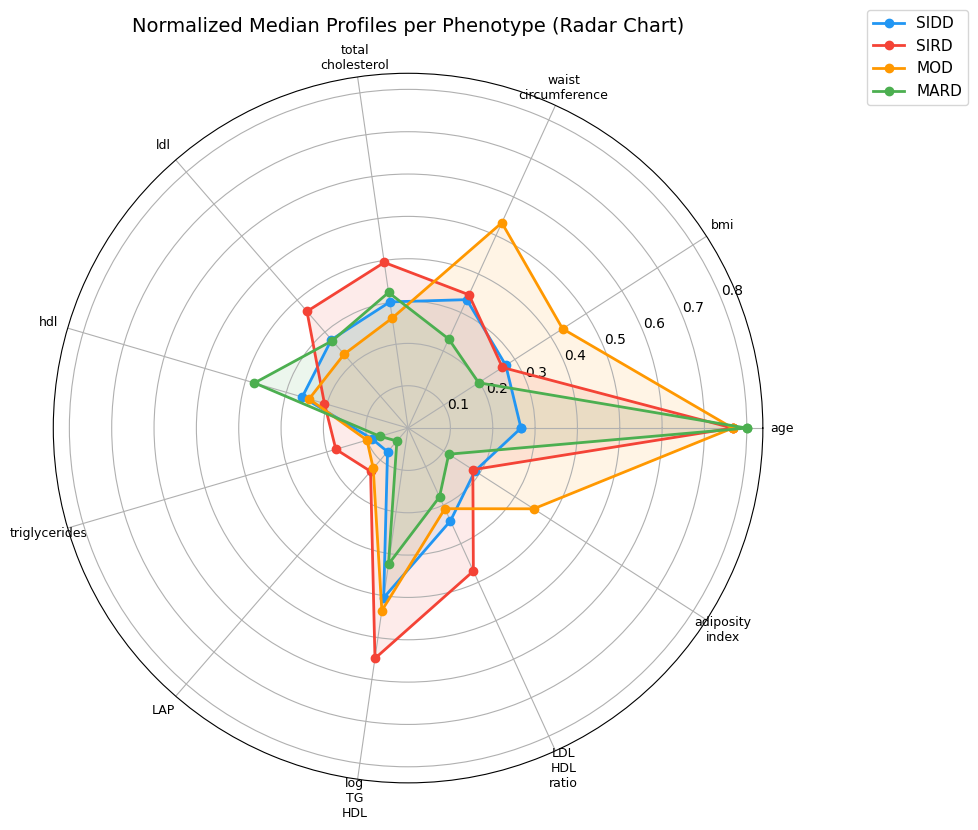

In [54]:
# --- 10a. Radar / Spider Chart: Normalized Medians per Phenotype ---

scaled_medians = df_clean.copy()
scaled_medians[clustering_features] = X_scaled_df.loc[df_clean.index, clustering_features]
radar_data = scaled_medians.groupby('phenotype')[clustering_features].median()
radar_data = radar_data.reindex(phenotype_order)

categories = clustering_features
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors = {'SIDD': '#2196F3', 'SIRD': '#f44336', 'MOD': '#FF9800', 'MARD': '#4CAF50'}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for pheno in phenotype_order:
    values = radar_data.loc[pheno].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=pheno, color=colors[pheno])
    ax.fill(angles, values, alpha=0.1, color=colors[pheno])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in categories], size=9)
ax.set_title('Normalized Median Profiles per Phenotype (Radar Chart)', size=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

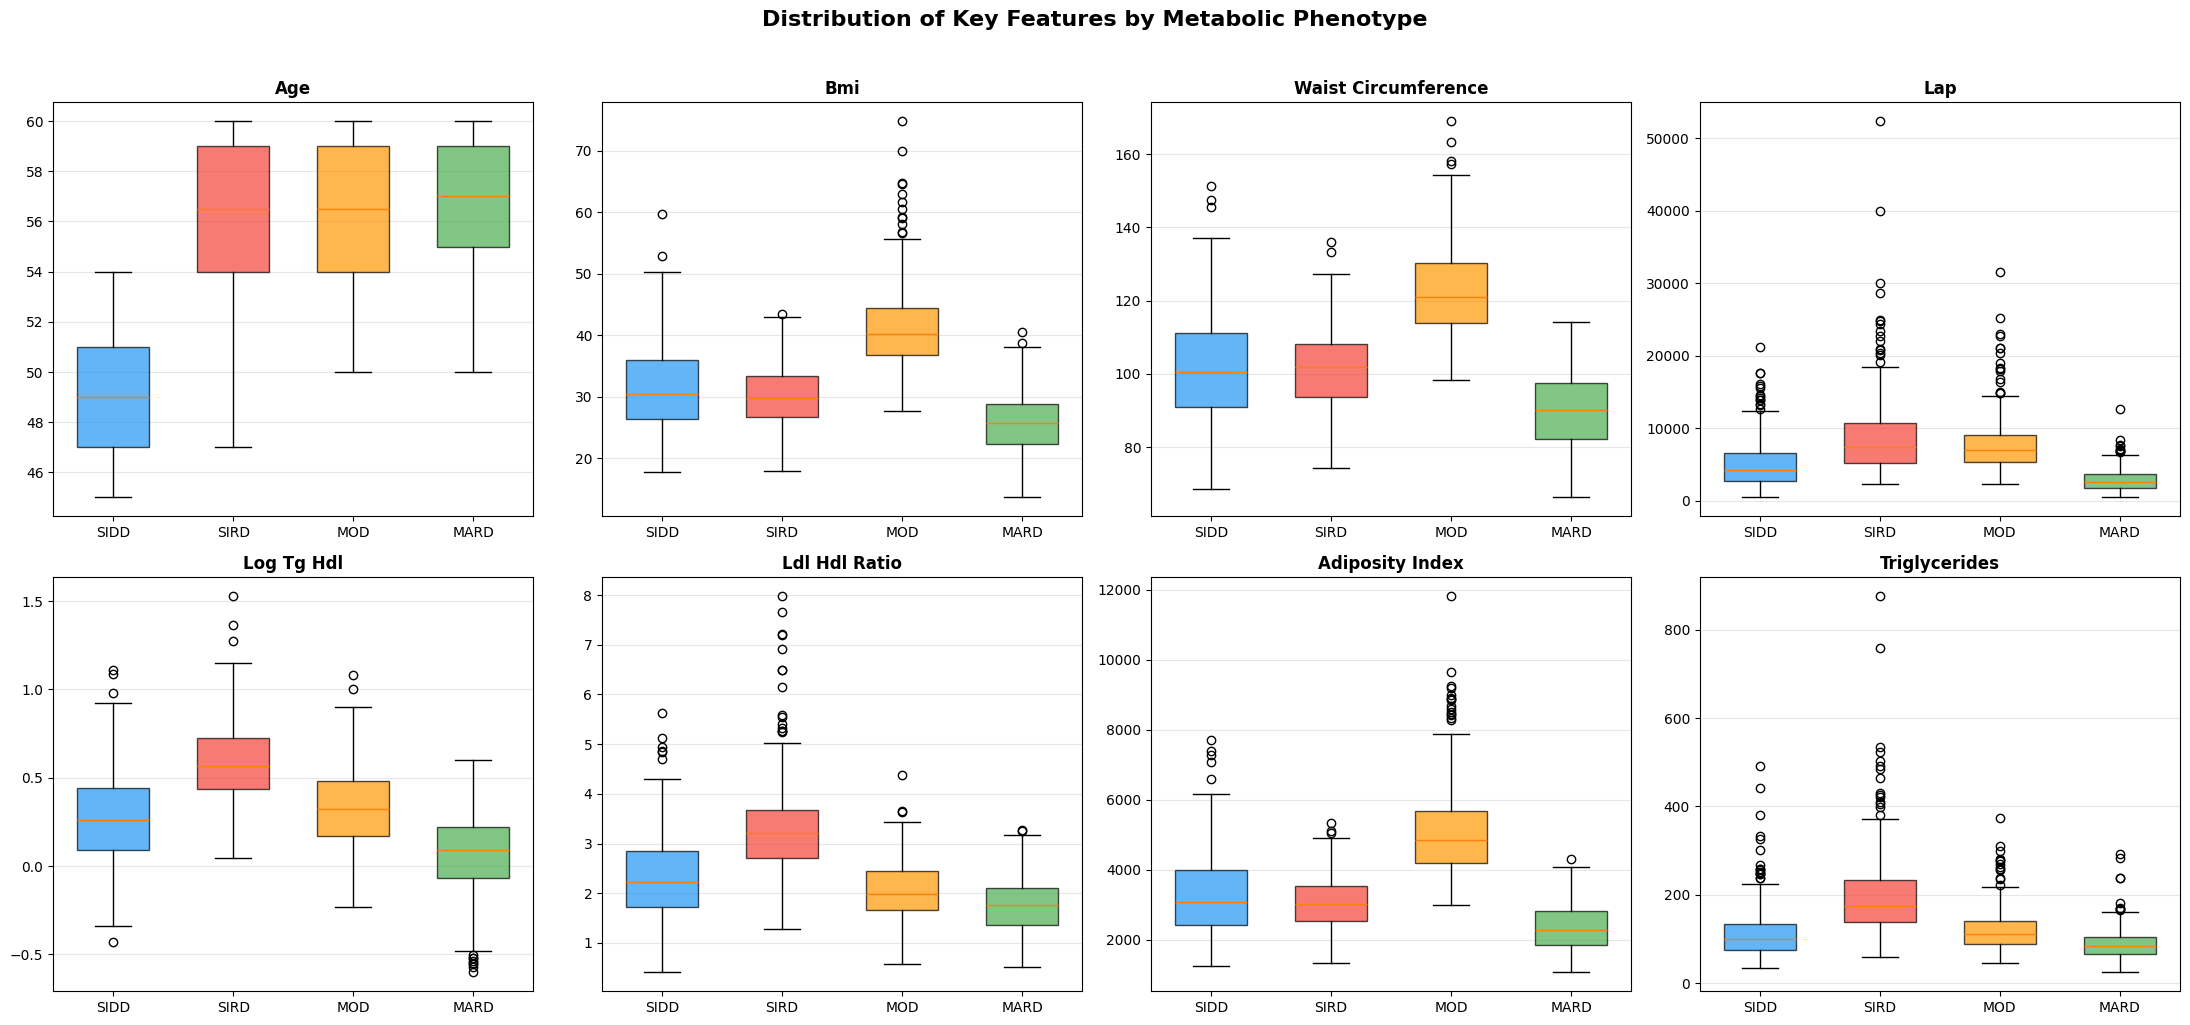

In [55]:
# --- 10b. Box Plots: Key Features by Phenotype ---

key_features = ['age', 'bmi', 'waist_circumference', 'LAP', 'log_TG_HDL', 'LDL_HDL_ratio', 'adiposity_index', 'triglycerides']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    data_by_pheno = [df_clean[df_clean['phenotype'] == p][feat].values for p in phenotype_order]
    bp = axes[i].boxplot(data_by_pheno, labels=phenotype_order, patch_artist=True, widths=0.6)
    for patch, pheno in zip(bp['boxes'], phenotype_order):
        patch.set_facecolor(colors[pheno])
        patch.set_alpha(0.7)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribution of Key Features by Metabolic Phenotype', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

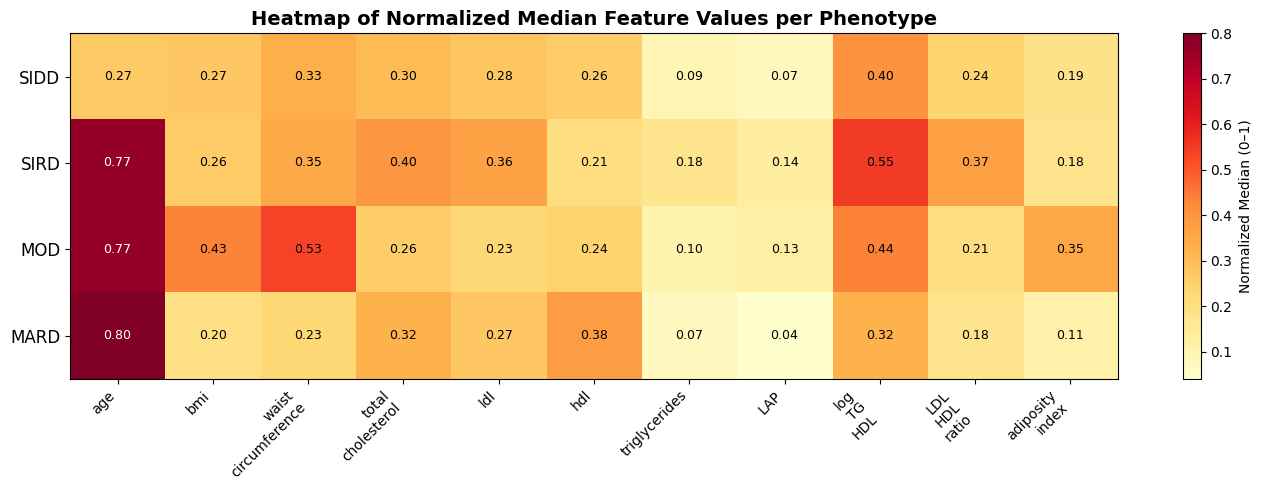

In [56]:
# --- 10c. Heatmap: Normalized Medians ---

fig, ax = plt.subplots(figsize=(14, 5))
heatmap_data = radar_data.values
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(N))
ax.set_xticklabels([f.replace('_', '\n') for f in categories], rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(phenotype_order)))
ax.set_yticklabels(phenotype_order, fontsize=12)

for i in range(len(phenotype_order)):
    for j in range(N):
        val = heatmap_data[i, j]
        text_color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=text_color)

plt.colorbar(im, ax=ax, label='Normalized Median (0–1)')
ax.set_title('Heatmap of Normalized Median Feature Values per Phenotype', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

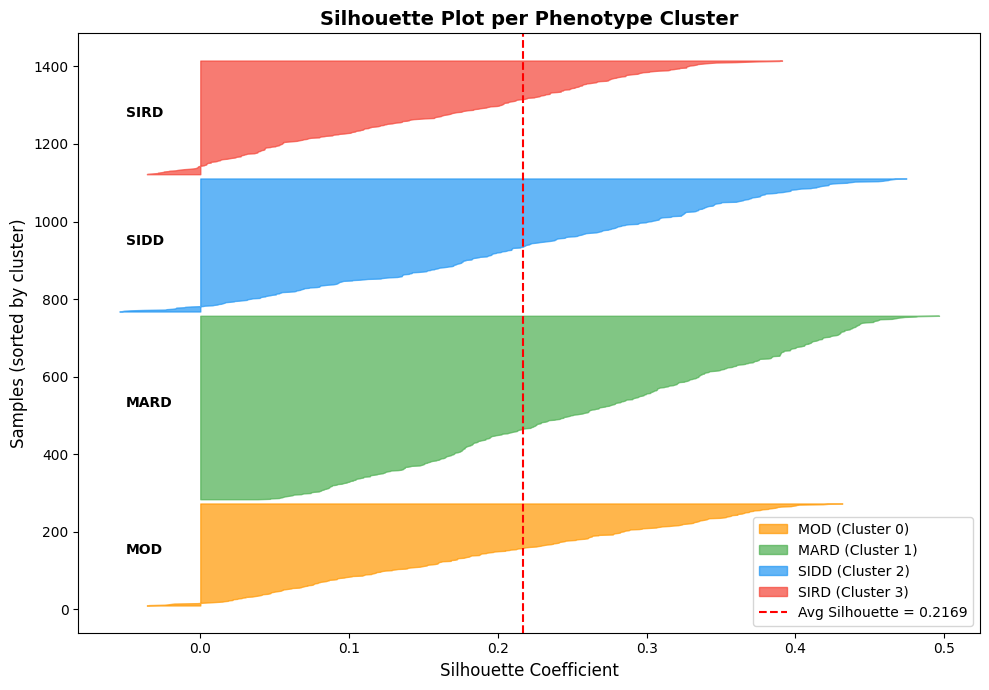

Average Silhouette Score: 0.2169


In [57]:
# --- 10d. Silhouette Analysis ---

sample_silhouette_values = silhouette_samples(X_scaled, df_clean['cluster'].values)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in sorted(labels.keys()):
    cluster_sil = sample_silhouette_values[df_clean['cluster'].values == i]
    cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     alpha=0.7, color=colors[labels[i]], label=f'{labels[i]} (Cluster {i})')
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sil), labels[i], fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', linewidth=1.5, label=f'Avg Silhouette = {sil_score:.4f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Samples (sorted by cluster)', fontsize=12)
ax.set_title('Silhouette Plot per Phenotype Cluster', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
print(f"Average Silhouette Score: {sil_score:.4f}")

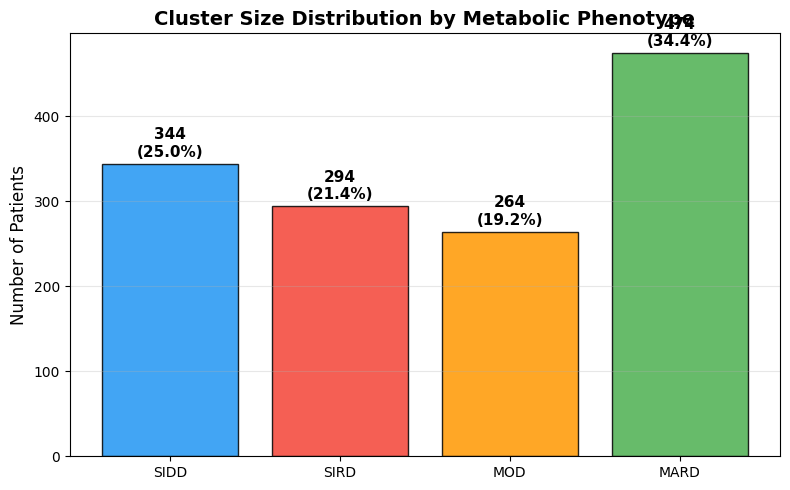

In [58]:
# --- 10e. Cluster Size Bar Chart ---

fig, ax = plt.subplots(figsize=(8, 5))
counts = df_clean['phenotype'].value_counts().reindex(phenotype_order)
bars = ax.bar(phenotype_order, counts.values, color=[colors[p] for p in phenotype_order], edgecolor='black', alpha=0.85)

for bar, count in zip(bars, counts.values):
    pct = count / len(df_clean) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Cluster Size Distribution by Metabolic Phenotype', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Clustered Dataset

In [59]:
# Display the final clustered dataset summary
output_cols = ['SEQN'] + clustering_features + ['cluster', 'phenotype']
df_output = df_clean[output_cols].copy()

# Summary table
summary = df_output['phenotype'].value_counts().reindex(phenotype_order).reset_index()
summary.columns = ['Phenotype', 'Count']
summary['%'] = (summary['Count'] / len(df_output) * 100).round(1).astype(str) + '%'
display(summary.style.hide(axis='index').set_caption(f'Final Clustered Dataset — {df_output.shape[0]} rows × {df_output.shape[1]} columns'))

display(df_output.head(10))

Phenotype,Count,%
SIDD,344,25.0%
SIRD,294,21.4%
MOD,264,19.2%
MARD,474,34.4%


,SEQN,age,bmi,waist_circumference,total_cholesterol,ldl,hdl,triglycerides,LAP,log_TG_HDL,LDL_HDL_ratio,adiposity_index,cluster,phenotype
0,130396.00,56.00,27.30,97.90,214.00,124.00,68.00,108.50,4329.15,0.20,1.82,2672.67,1,MARD
1,130416.00,59.00,32.90,88.30,189.00,126.00,47.00,90.80,2751.24,0.29,2.68,2905.07,1,MARD
2,130599.00,54.00,50.20,133.00,184.00,125.00,41.00,172.20,12915.00,0.62,3.05,6676.60,0,MOD
3,130662.00,52.00,30.90,98.80,191.00,119.00,53.00,73.90,3015.12,0.14,2.25,3052.92,2,SIDD
4,130703.00,51.00,39.20,126.20,207.00,102.00,49.00,200.50,13674.10,0.61,2.08,4947.04,0,MOD
5,130720.00,46.00,23.80,76.50,155.00,74.00,67.00,72.30,1337.55,0.03,1.10,1820.70,2,SIDD
6,130791.00,52.00,36.80,117.00,178.00,110.00,45.00,103.20,6088.80,0.36,2.44,4305.60,2,SIDD
7,130807.00,60.00,20.90,79.00,139.00,69.00,60.00,86.30,1812.30,0.16,1.15,1651.10,1,MARD
8,130964.00,58.00,27.20,96.70,250.00,151.00,79.00,93.40,3614.58,0.07,1.91,2630.24,1,MARD
9,131083.00,52.00,40.70,120.50,176.00,76.00,56.00,143.20,8950.00,0.41,1.36,4904.35,0,MOD


---
## 12. Summary

### Key Findings
- **4 distinct metabolic phenotypes** were identified using K-Means (k=4) with proxy features derived from demographics, adiposity, and lipid metabolism.
- **Excluded variables:** HbA1c, FBS, systolic BP, diastolic BP — demonstrating that metabolic phenotypes can be uncovered through adiposity and lipid-based proxies alone.
- **Engineered proxies** (LAP, log TG/HDL, LDL/HDL ratio, Adiposity Index) provided strong signals for cluster separation.

### Phenotype Summary
| Phenotype | Key Characteristics | Clinical Priority |
|-----------|--------------------|---------|
| **SIRD** | Highest visceral fat (LAP), insulin resistance markers | Weight loss + insulin sensitizers |
| **SIDD** | Younger, leaner — beta-cell dysfunction | Monitor beta-cell function, consider insulin |
| **MARD** | Oldest, mild lipid profiles | Conservative management, geriatric screening |
| **MOD** | Moderate obesity, younger | Lifestyle + metformin |